# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


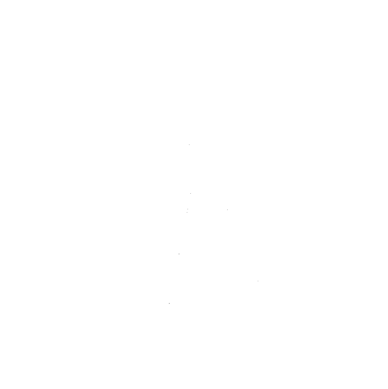

Threshold value: 50


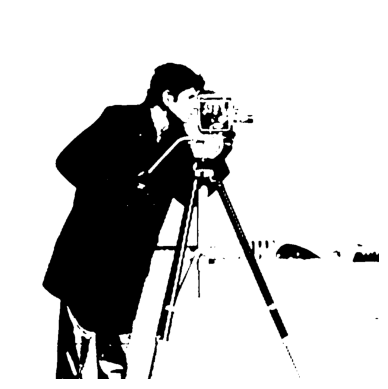

Threshold value: 100


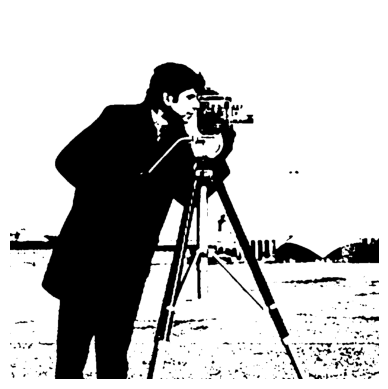

Threshold value: 150


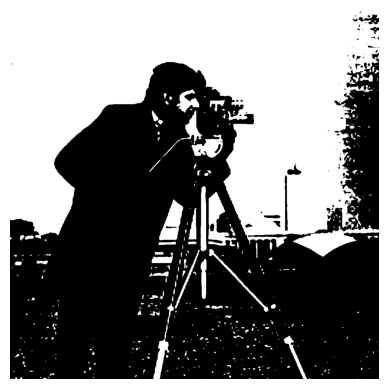

Threshold value: 200


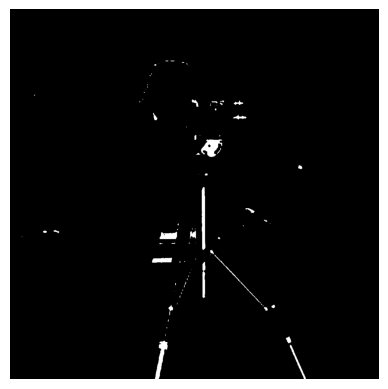

In [3]:
import cv2
import matplotlib
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) # THRESH_BINARY 255 or 0

    print(f"Threshold value: {threshold_value}")
    #cv2_imshow(thresh_img)

    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()


# if pixel > threshold be 255 else 0


Original Image: 


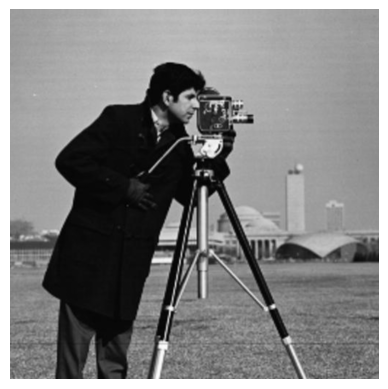

In [5]:
print("Original Image: ")
#cv2_imshow(img)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


## Histograms

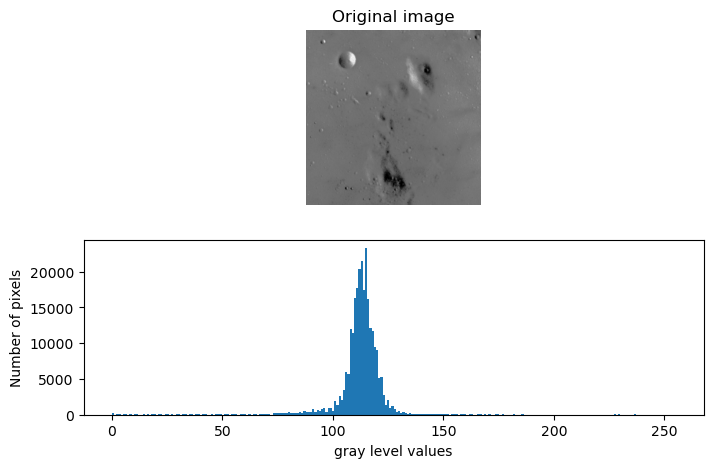

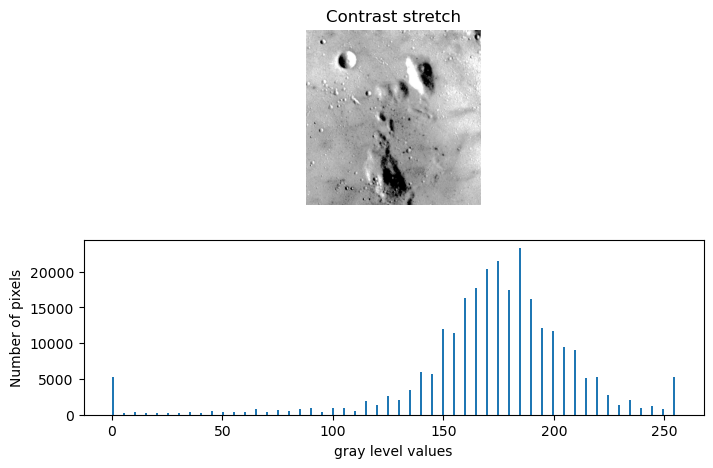

In [6]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np  # for arry and mathmatical but here for Contrast stretching

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching we ude with it useful range to make details more cleare
# 1 make percentile by reduse range to make image better with details and when we want to make more details we reduse range more
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98)) # we make here Contrast stretching for range 2, 98

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) # img.flat because histogram can not prsent image in 2D so fit make it 1D
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


## Task 1

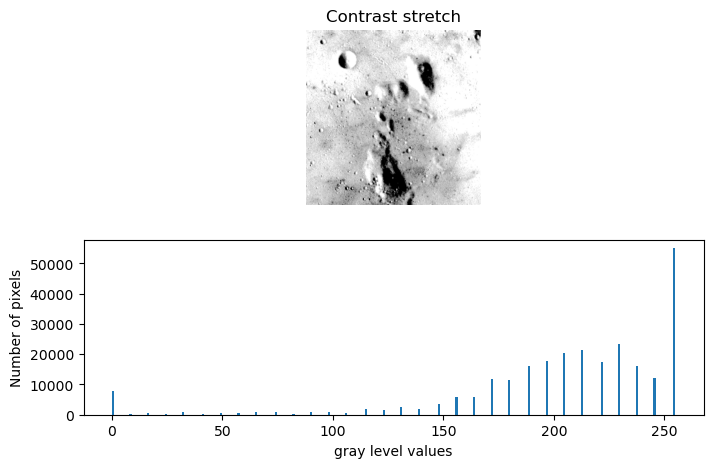

In [12]:
img = data.moon()

p3, p80 = np.percentile(img, (3, 80))

img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))

fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.show()

## Task 2

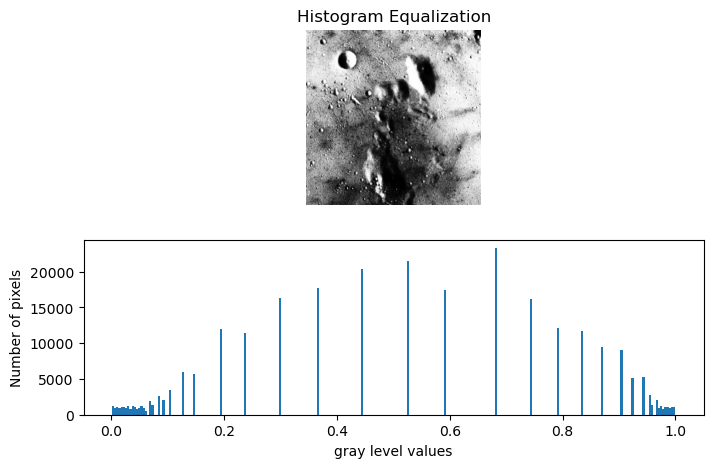

In [8]:
img = data.moon()

img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))

fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalization')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256)
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')

plt.show()

## Task 3

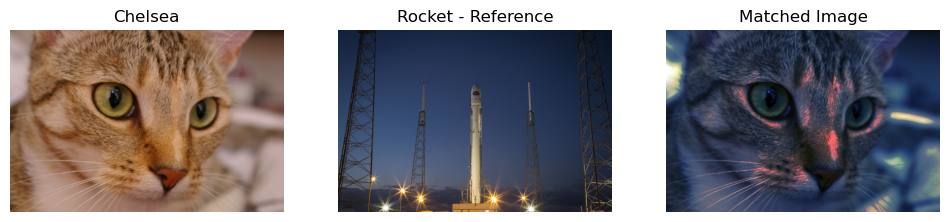

In [11]:
from skimage.exposure import match_histograms

reference = data.rocket()
image = data.chelsea()

matched = match_histograms(image, reference, channel_axis=-1)

fig = plt.figure(figsize=(12, 8))

fig.add_subplot(1, 3, 1)
plt.imshow(image)
plt.axis('off')
plt.title('Chelsea')

fig.add_subplot(1, 3, 2)
plt.imshow(reference)
plt.axis('off')
plt.title('Rocket - Reference')

fig.add_subplot(1, 3, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Matched Image')

plt.show()